# Support Ticket Classifier
Route a support ticket from its text. **The target changed on purpose:** department labels proved unreliable (Checkpoint), so the model predicts ticket **type** — Incident, Request, Problem, Change. Data: [Kaggle multilingual support tickets](https://www.kaggle.com/datasets/tobiasbueck/multilingual-customer-support-tickets) — synthetic, English tickets only. Rule throughout: learn from train only; open the test set once, at the end.

# Phase 1 — Understand the data
*Descriptive only — nothing measured here feeds the model.*

## Step 1 — Setup: seed, chart style, library versions

In [1]:
# Step 1 — imports, seed, display settings
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path("data")
LABEL = "queue"
TEXT_COLS = ["subject", "body"]

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

# Chart palette — colour-blind-safe categorical order (validated), one-hue blue ramp for magnitudes
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)

mpl.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlecolor": INK,
    "legend.frameon": False,
})

def headline(ax, title, subtitle, hbar=False):
    """Left-aligned bold title with a one-line subtitle; hbar=True also tidies a horizontal bar chart."""
    ax.set_title(title, pad=24)
    ax.text(0, 1.03, subtitle, transform=ax.transAxes, fontsize=9.5, color=INK_2)
    if hbar:
        ax.grid(axis="y", visible=False)
        ax.tick_params(axis="y", length=0)

ENV_VERSIONS = {
    "python": sys.version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": mpl.__version__,
    "seaborn": sns.__version__,
}
print(f"SEED = {SEED}")
print(" | ".join(f"{k} {v}" for k, v in ENV_VERSIONS.items()))

SEED = 42
python 3.11.14 | pandas 3.0.6 | numpy 2.4.6 | scikit-learn 1.9.1 | matplotlib 3.11.2 | seaborn 0.13.2


## Step 2 — Load the data (synthetic tickets: results prove the method, not real-inbox performance)

In [2]:
# Step 2 — load CSV into df_raw
DATA_FILE = DATA_DIR / "aa_dataset-tickets-multi-lang-5-2-50-version.csv"
df_raw = pd.read_csv(DATA_FILE)

assert LABEL in df_raw.columns, f"label column '{LABEL}' missing from {DATA_FILE.name}"
assert set(TEXT_COLS) <= set(df_raw.columns), f"text columns {TEXT_COLS} missing from {DATA_FILE.name}"

print(f"Loaded {DATA_FILE.name}: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

Loaded aa_dataset-tickets-multi-lang-5-2-50-version.csv: 28,587 rows × 16 columns


## Step 3 — Rule out leaky columns
**Decision:** the model may only use what the customer wrote (`subject`, `body`); answer, type, priority and tags are added after handling.

In [3]:
# Step 3 (leakage audit) — tag every column by when it exists in a ticket's life
COLUMN_ROLES = {
    "subject":  ("available at routing", "Written by the customer"),
    "body":     ("available at routing", "Written by the customer"),
    "language": ("available at routing", "Detectable from the text the moment it arrives"),
    "queue":    ("label",                "The department — what the model predicts"),
    "answer":   ("added after handling", "The agent's reply, written after the ticket was routed"),
    "type":     ("added after handling", "Incident / Request / Problem / Change, set during triage"),
    "priority": ("added after handling", "Set during triage (some portals let customers pick it — excluded to stay conservative)"),
    "version":  ("dataset metadata",     "Generation batch of this synthetic dataset, not a property of a ticket"),
    **{f"tag_{i}": ("added after handling", "Topic tag applied after the ticket was read") for i in range(1, 9)},
}
assert set(COLUMN_ROLES) == set(df_raw.columns), "every column must be classified before modelling"

column_roles = pd.DataFrame(COLUMN_ROLES, index=["role", "why"]).T
ROLE_COLORS = dict(zip(["available at routing", "added after handling", "dataset metadata", "label"], CAT))

print("Model may use:", column_roles.index[column_roles["role"] == "available at routing"].tolist())
batch_mix = pd.crosstab(df_raw[LABEL], df_raw["version"], normalize="columns")
print(f"Generation batches (version): department mix differs by at most "
      f"{(batch_mix.max(axis=1) - batch_mix.min(axis=1)).max() * 100:.1f} points across the 3 batches")
column_roles.sort_values("role")

Model may use: ['subject', 'body', 'language']
Generation batches (version): department mix differs by at most 2.6 points across the 3 batches


,role,why
answer,added after handling,"The agent's reply, written after the ticket was routed"
type,added after handling,"Incident / Request / Problem / Change, set during triage"
priority,added after handling,Set during triage (some portals let customers pick it — excluded to stay conservative)
tag_1,added after handling,Topic tag applied after the ticket was read
tag_2,added after handling,Topic tag applied after the ticket was read
tag_3,added after handling,Topic tag applied after the ticket was read
tag_4,added after handling,Topic tag applied after the ticket was read
tag_5,added after handling,Topic tag applied after the ticket was read
tag_6,added after handling,Topic tag applied after the ticket was read
tag_7,added after handling,Topic tag applied after the ticket was read


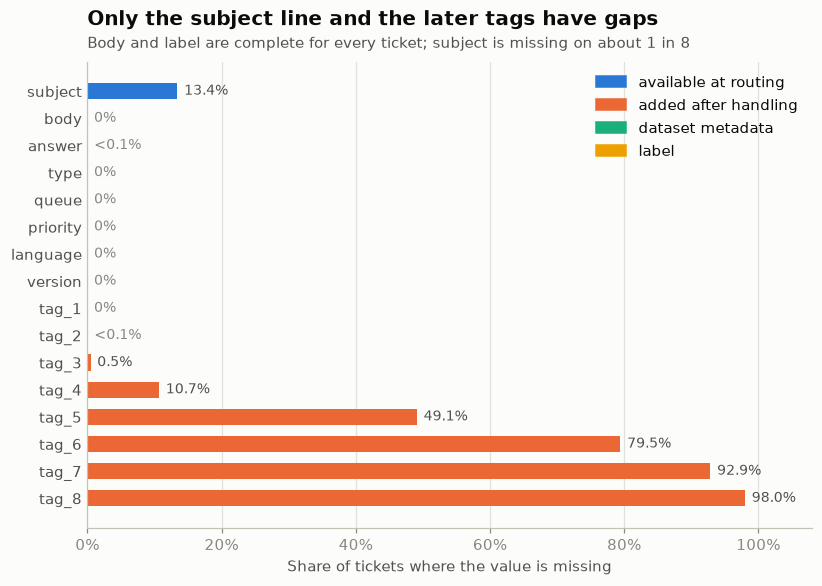

In [4]:
# Step 3 (chart 1) — missing values by column, coloured by role
missing_pct = df_raw.isna().mean().mul(100)[::-1]  # reversed so the first column sits at the top

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(missing_pct.index, missing_pct.values, height=0.6,
        color=[ROLE_COLORS[COLUMN_ROLES[c][0]] for c in missing_pct.index])
for y, v in enumerate(missing_pct.values):
    label = f"{v:.1f}%" if v >= 0.05 else ("<0.1%" if v > 0 else "0%")
    ax.text(v + 1, y, label, va="center", fontsize=9, color=INK_2 if v >= 0.05 else MUTED)

ax.set_xlim(0, 108)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter())
ax.set_xlabel("Share of tickets where the value is missing")
headline(ax, "Only the subject line and the later tags have gaps",
         "Body and label are complete for every ticket; subject is missing on about 1 in 8", hbar=True)
ax.legend(handles=[Patch(color=c, label=r) for r, c in ROLE_COLORS.items()], loc="upper right")
plt.show()

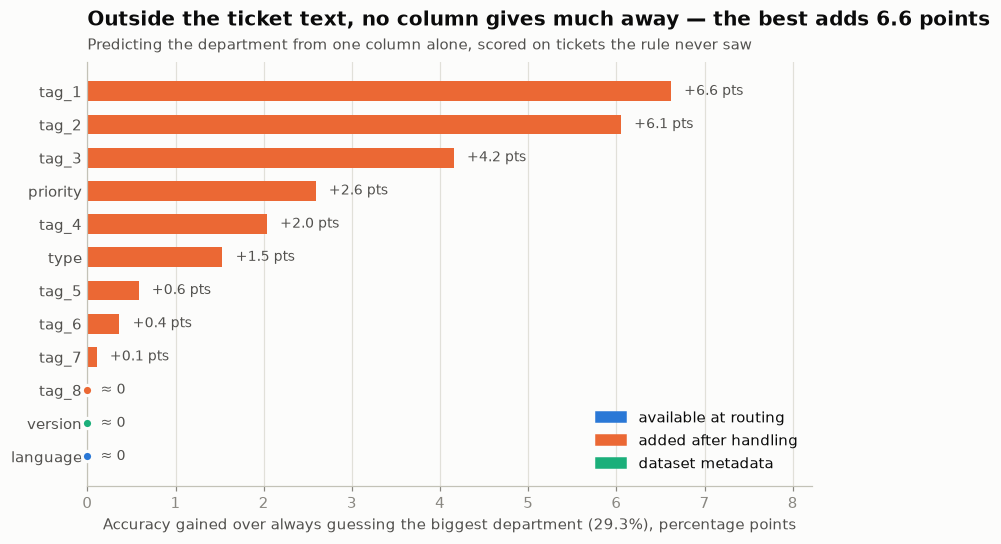

In [5]:
# Step 3 (chart 2) — how much would each non-text column give away about the department?
# Rule: predict the most common department for each value of the column. The rule is learned on one
# half of the tickets and scored on the other, so columns with hundreds of values can't just memorise.
from sklearn.model_selection import train_test_split

lookup_cols = [c for c in df_raw.columns if c not in TEXT_COLS + ["answer", LABEL]]
X_lookup = df_raw[lookup_cols].astype(str).fillna("<missing>")
X_learn, X_score, y_learn, y_score = train_test_split(
    X_lookup, df_raw[LABEL], test_size=0.5, random_state=SEED, stratify=df_raw[LABEL]
)
fallback = y_learn.mode()[0]
lookup_floor = (y_score == fallback).mean()

def lookup_accuracy(col):
    most_common_dept = y_learn.groupby(X_learn[col]).agg(lambda s: s.mode()[0])
    return (X_score[col].map(most_common_dept).fillna(fallback) == y_score).mean()

lift = pd.Series({c: lookup_accuracy(c) - lookup_floor for c in lookup_cols}).mul(100).sort_values()
lift_colors = [ROLE_COLORS[COLUMN_ROLES[c][0]] for c in lift.index]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(lift.index, lift.values, height=0.6, color=lift_colors)
for y, (v, color) in enumerate(zip(lift.values, lift_colors)):
    if v < 0.05:  # a zero-length bar is invisible, so mark it with a dot in its role colour
        ax.scatter(0, y, s=45, color=color, edgecolor=SURFACE, linewidth=2, zorder=3, clip_on=False)
    ax.text(max(v, 0) + 0.15, y, f"+{v:.1f} pts" if v >= 0.05 else "≈ 0", va="center", fontsize=9, color=INK_2)

ax.set_xlim(0, lift.max() + 1.6)
ax.set_xlabel(f"Accuracy gained over always guessing the biggest department ({lookup_floor:.1%}), percentage points")
headline(ax, f"Outside the ticket text, no column gives much away — the best adds {lift.max():.1f} points",
         "Predicting the department from one column alone, scored on tickets the rule never saw", hbar=True)
roles_shown = {COLUMN_ROLES[c][0] for c in lookup_cols}
ax.legend(handles=[Patch(color=c, label=r) for r, c in ROLE_COLORS.items() if r in roles_shown], loc="lower right")
plt.show()

In [6]:
# Step 3 (probe) — one column at a time is the weakest possible test. The fairer test: a real model
# given the excluded columns together, learned and scored on the same two halves as chart 2.
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

TAG_COLS = [f"tag_{i}" for i in range(1, 9)]

def after_handling_tokens(row, cols):
    # a tag counts the same whichever slot it sits in; type and priority keep their column name
    return [f"tag={v}" if c.startswith("tag_") else f"{c}={v}" for c, v in row[cols].dropna().items()]

probe = {}
for name, cols in [("all 8 tags together", TAG_COLS), ("tags + type + priority", TAG_COLS + ["type", "priority"])]:
    tokens = df_raw.apply(after_handling_tokens, axis=1, cols=cols)
    vec = CountVectorizer(analyzer=lambda toks: toks, binary=True)
    X_probe_learn = vec.fit_transform(tokens.loc[X_learn.index])
    pred = LogisticRegression(max_iter=2000).fit(X_probe_learn, y_learn).predict(vec.transform(tokens.loc[X_score.index]))
    acc = accuracy_score(y_score, pred)
    probe[name] = {"accuracy": acc, "gain over floor (pts)": (acc - lookup_floor) * 100,
                   "macro F1": f1_score(y_score, pred, average="macro")}

pd.DataFrame(probe).T.round(3)

,accuracy,gain over floor (pts),macro F1
all 8 tags together,0.375,8.206,0.233
tags + type + priority,0.422,12.977,0.283


*Excluded columns carry moderate signal (~13 points together) — excluded anyway, because they don't exist when a ticket arrives.*

## Step 4 — Study the label: imbalance and the floors every model must beat

In [7]:
# Step 4 — value_counts on the label, imbalance ratio, accuracy floor + macro-F1 floor
class_counts = df_raw[LABEL].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"{len(class_counts)} departments | largest: {class_counts.index[0]} ({class_counts.iloc[0]:,}) | "
      f"smallest: {class_counts.index[-1]} ({class_counts.iloc[-1]:,}) | imbalance ratio {imbalance_ratio:.1f}×\n")

# Floors = scores with no intelligence, using only how common each department is (share p).
# Computed exactly from the shares — no random draw, so the numbers never wobble between runs.
p = class_counts / class_counts.sum()
floors_all_tickets = pd.DataFrame(
    {"accuracy": [p.max(), (p ** 2).sum()],
     "macro F1": [2 * p.max() / (1 + p.max()) / len(p), 1 / len(p)]},
    index=["always guess the biggest department", "guess at random, in proportion to department size"],
)
floors_all_tickets.round(3)

10 departments | largest: Technical Support (8,362) | smallest: General Inquiry (405) | imbalance ratio 20.6×



,accuracy,macro F1
always guess the biggest department,0.293,0.045
"guess at random, in proportion to department size",0.171,0.100


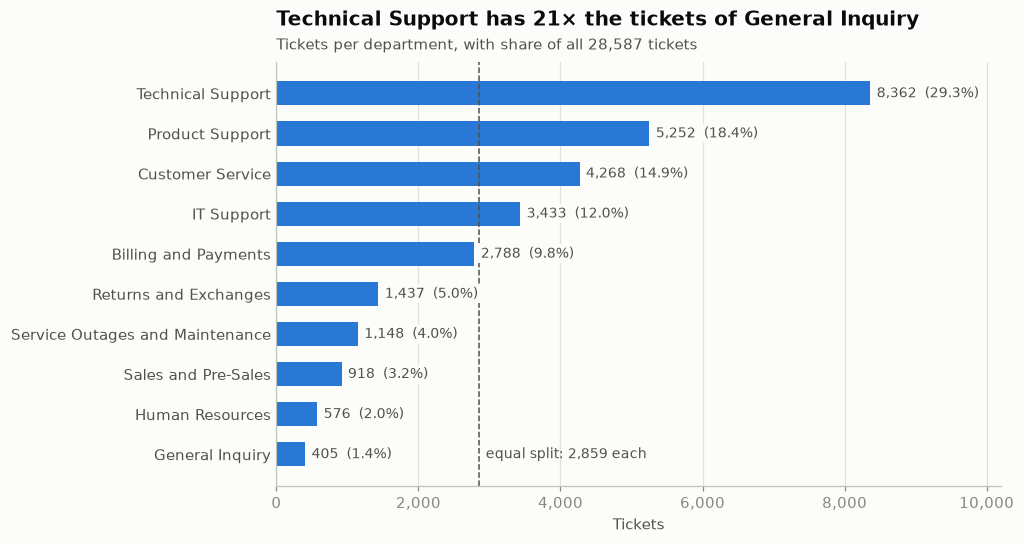

In [8]:
# Step 4 (plot) — horizontal bar chart of tickets per department
shares = class_counts / class_counts.sum()
equal_split = class_counts.sum() / len(class_counts)
label_box = dict(facecolor=SURFACE, edgecolor="none", pad=1.5)  # lets the reference line pass behind labels

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(class_counts.index[::-1], class_counts.values[::-1], height=0.6, color=CAT[0])
ax.axvline(equal_split, color=INK_2, linestyle="--", linewidth=1, zorder=1)
for y, (n, s) in enumerate(zip(class_counts.values[::-1], shares.values[::-1])):
    ax.text(n + 90, y, f"{n:,}  ({s:.1%})", va="center", fontsize=9, color=INK_2, bbox=label_box, zorder=2)
ax.text(equal_split + 90, 0, f"equal split: {equal_split:,.0f} each", va="center", fontsize=9, color=INK_2)

ax.set_xlim(0, class_counts.max() * 1.22)
ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Tickets")
headline(ax, f"{class_counts.index[0]} has {imbalance_ratio:.0f}× the tickets of {class_counts.index[-1]}",
         f"Tickets per department, with share of all {class_counts.sum():,} tickets", hbar=True)
plt.show()

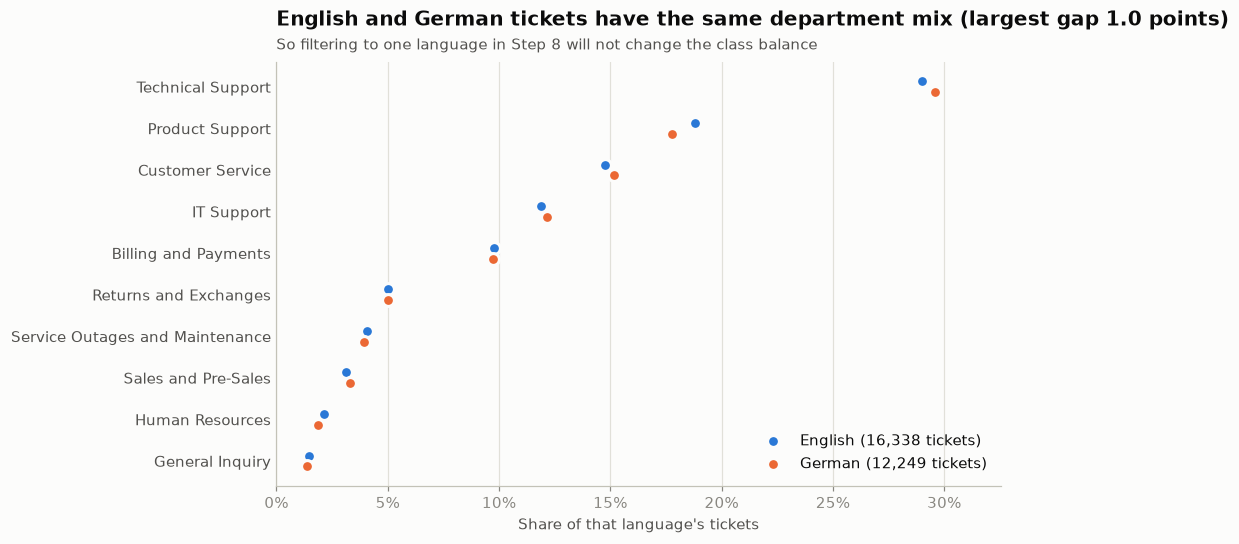

language,de,en
queue,,
Technical Support,29.6,29.0
Product Support,17.8,18.8
Customer Service,15.2,14.8
IT Support,12.2,11.9
Billing and Payments,9.7,9.8
Returns and Exchanges,5.0,5.0
Service Outages and Maintenance,4.0,4.1
Sales and Pre-Sales,3.3,3.1
Human Resources,1.9,2.1


In [9]:
# Step 4 (language) — department share by language
lang_counts = df_raw["language"].value_counts()
lang_mix = pd.crosstab(df_raw[LABEL], df_raw["language"], normalize="columns").mul(100).loc[class_counts.index[::-1]]
lang_gap = (lang_mix["en"] - lang_mix["de"]).abs().max()

fig, ax = plt.subplots(figsize=(8.5, 5))
rows = np.arange(len(lang_mix))
# English sits slightly above, German slightly below, so equal shares never hide one dot behind the other
for (code, name), color, offset in zip([("en", "English"), ("de", "German")], CAT, [0.13, -0.13]):
    ax.scatter(lang_mix[code], rows + offset, s=60, color=color, edgecolor=SURFACE, linewidth=2, zorder=3,
               label=f"{name} ({lang_counts[code]:,} tickets)")

ax.set_yticks(rows, lang_mix.index)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
ax.set_xlim(0, lang_mix.max().max() * 1.1)
ax.set_xlabel("Share of that language's tickets")
headline(ax, f"English and German tickets have the same department mix (largest gap {lang_gap:.1f} points)",
         "So filtering to one language in Step 8 will not change the class balance", hbar=True)
ax.legend(loc="lower right")
plt.show()

lang_mix.round(1).iloc[::-1]

In [10]:
# Step 4 (read) — print 2 sample tickets per department to judge how separable they are
# English only, so any reader can judge them. The seed means everyone sees the same tickets.
SAMPLES_PER_DEPT = 2
samples = (df_raw[df_raw["language"] == "en"]
           .groupby(LABEL, group_keys=False)
           .sample(SAMPLES_PER_DEPT, random_state=SEED))

for dept in class_counts.index:
    print(f"━━ {dept} " + "━" * max(3, 60 - len(dept)))
    for _, row in samples[samples[LABEL] == dept].iterrows():
        subject = row["subject"] if pd.notna(row["subject"]) else "(no subject)"
        body = " ".join(row["body"].split())
        print(f"  ▸ {subject}\n    {body[:200]}{'…' if len(body) > 200 else ''}\n")

━━ Technical Support ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▸ Concern About Recent Decline in Digital Campaign Metrics
    We have noticed a sudden drop in the performance metrics of our digital campaign. This may be due to recent software updates or configuration changes. Despite our efforts to troubleshoot by reviewing …

  ▸ Failure in High-Intensity Projector Automation Process
    Dear Support Team,\n\nI am submitting a report regarding an issue with the automation process of our high-brightness projector system. Recently, I have experienced repeated failures in the automation …

━━ Product Support ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▸ Concerns Regarding Security of Medical Information
    Facing difficulties in securing medical information within our hospital's IT system. The problem might stem from outdated security protocols. Efforts have been made to update firewall settings and per…

  ▸ Digital Strategy Challenge
    Facing difficulties in implementing the

*Imbalance ~21:1; floors 29.3% accuracy / 0.10 macro F1. Several sampled tickets don't fit their department — first sign of label noise.*

---
# Phase 2 — Clean the data

In [11]:
# Step 5 — build the text field: combine subject + body into a single text column, add length columns
df = df_raw.copy()
df["text"] = (df["subject"].fillna("") + " " + df["body"].fillna("")).str.strip()
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

print(f"Tickets with no subject: {df['subject'].isna().sum():,} — their text is the body alone")

Tickets with no subject: 3,838 — their text is the body alone


## Steps 6–7 — Drop empty rows and exact duplicates
**Decision:** short tickets stay — production receives them too.

No label:                 0 rows
No text in ['subject', 'body']: 0 rows
Exact duplicate texts:    0 rows
Remaining:                28,587 of 28,587


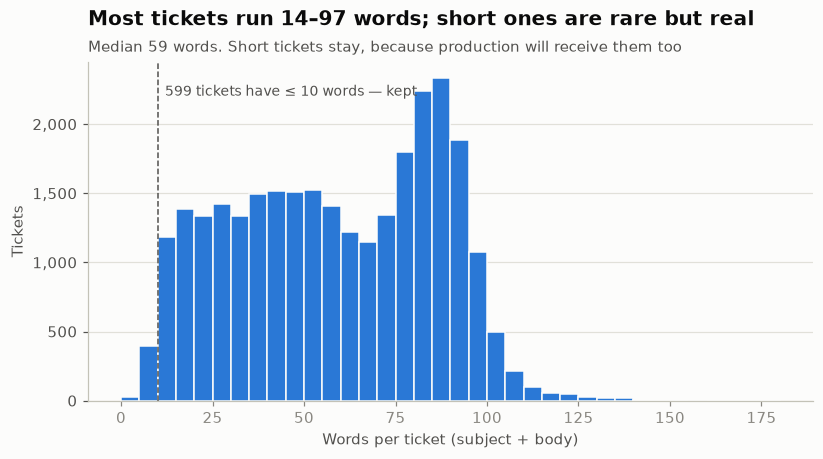

In [12]:
# Steps 6–7 — drop rows with no label or no text, then exact duplicate texts; report counts
rows_at_start = len(df)
no_label = df[LABEL].isna()
no_text = df[TEXT_COLS].isna().all(axis=1) | (df["text"] == "")

print(f"No label:                 {no_label.sum():,} rows")
print(f"No text in {TEXT_COLS}: {no_text.sum():,} rows")
df = df[~(no_label | no_text)].copy()
dupes = df["text"].duplicated()
print(f"Exact duplicate texts:    {dupes.sum():,} rows")
df = df[~dupes].copy()
print(f"Remaining:                {len(df):,} of {rows_at_start:,}")

# How short do tickets get? Shown, not filtered.
SHORT_WORDS = 10
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(df["n_words"], bins=np.arange(0, df["n_words"].max() + 5, 5), color=CAT[0], edgecolor=SURFACE, linewidth=1)
ax.axvline(SHORT_WORDS, color=INK_2, linestyle="--", linewidth=1)
ax.text(SHORT_WORDS + 2, ax.get_ylim()[1] * 0.9, f"{(df['n_words'] <= SHORT_WORDS).sum():,} tickets have "
        f"≤ {SHORT_WORDS} words — kept", fontsize=9, color=INK_2)
ax.grid(axis="x", visible=False)
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Words per ticket (subject + body)")
ax.set_ylabel("Tickets")
headline(ax, f"Most tickets run {df['n_words'].quantile(.05):.0f}–{df['n_words'].quantile(.95):.0f} words; short ones are rare but real",
         f"Median {df['n_words'].median():.0f} words. Short tickets stay, because production will receive them too")
plt.show()

## Step 8 — English only
**Decision:** model the 16,338 English tickets. Every example stays readable, and translated copies (invisible to word-based family detection) can't leak across the split. Cost: no German routing.

In [13]:
# Step 8 — keep English tickets only (decision and reasons in the text above)
LANGUAGE = "en"
print(df["language"].value_counts().rename("tickets").to_string())
df = df[df["language"] == LANGUAGE].copy()
print(f"\nModelling set: {len(df):,} tickets in '{LANGUAGE}'")

language
en    16338
de    12249

Modelling set: 16,338 tickets in 'en'


## Step 9 — Light cleaning: remove `\n` and `<br>` leftovers before tokenising; no stemming or stopword removal

In [14]:
# Step 9 — replace formatting leftovers with spaces, apply safety-net placeholders, show before/after
FORMATTING = r"\\n|<br\s*/?>"   # a literal backslash-n, and HTML line breaks
SAFETY_NET = {
    "email address": (r"[\w.+-]+@[\w-]+\.[\w.]+", " <email> "),
    "URL":           (r"https?://\S+|www\.\S+", " <url> "),
    "long number":   (r"\b\d{5,}\b", " <num> "),
}

has_formatting = df["text"].str.contains(FORMATTING, regex=True)
example_idx = df.index[has_formatting][0]
before = df.at[example_idx, "text"]

print(f"{'formatting leftovers':22s} in {has_formatting.sum():,} tickets → replaced with a space")
df["text"] = df["text"].str.replace(FORMATTING, " ", regex=True)
for name, (pattern, placeholder) in SAFETY_NET.items():
    print(f"{name:22s} in {df['text'].str.contains(pattern, regex=True).sum():,} tickets → {placeholder.strip()}")
    df["text"] = df["text"].str.replace(pattern, placeholder, regex=True)

df["text"] = df["text"].str.split().str.join(" ")   # collapse the spaces left behind
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

placeholders = df["text"].str.findall(r"<[a-z_]+>").explode().value_counts()
print(f"\nPlaceholders now in the text (dataset's own + safety net): {placeholders.to_dict()}")
print(f"\nBEFORE: {before[:230]}…\nAFTER:  {df.at[example_idx, 'text'][:230]}…")

formatting leftovers   in 1,082 tickets → replaced with a space


email address          in 0 tickets → <email>


URL                    in 0 tickets → <url>
long number            in 14 tickets → <num>



Placeholders now in the text (dataset's own + safety net): {'<tel_num>': 180, '<acc_num>': 39, '<num>': 14, '<name>': 8, '<email>': 2}

BEFORE: Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settin…
AFTER:  Account Disruption Dear Customer Support Team, I am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings,…


## Step 10 — Find families of reworded tickets
**Decision:** the generator reworded tickets into families that share a label. Each family must stay on one side of every split, or the model scores by recognition. Families = tickets linked at similarity ≥ 0.60, the threshold chosen from the chart below.

In [15]:
# Step 10 — link tickets whose similarity is >= FAMILY_THRESHOLD; each connected group is one family
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import TfidfVectorizer

FAMILY_THRESHOLD = 0.60
df = df.reset_index(drop=True)
X_sim = TfidfVectorizer(sublinear_tf=True, min_df=2).fit_transform(df["text"])
n = X_sim.shape[0]

nearest_sim, nearest_idx = np.zeros(n), np.zeros(n, dtype=int)
edge_rows, edge_cols = [], []
for start in range(0, n, 1000):  # in blocks, so the full n × n similarity matrix never sits in memory
    block = (X_sim[start:start + 1000] @ X_sim.T).toarray()
    rows = np.arange(block.shape[0])
    block[rows, start + rows] = 0  # a ticket is not its own neighbour
    nearest_sim[start + rows] = block.max(axis=1)
    nearest_idx[start + rows] = block.argmax(axis=1)
    r, c = np.nonzero(block >= FAMILY_THRESHOLD)
    edge_rows.append(r + start)
    edge_cols.append(c)

links = coo_matrix((np.ones(sum(map(len, edge_rows))), (np.concatenate(edge_rows), np.concatenate(edge_cols))), shape=(n, n))
n_families, family_id = connected_components(links, directed=False)
df["family_id"] = family_id

family_size = df["family_id"].map(df["family_id"].value_counts())
print(f"{n:,} tickets → {n_families:,} families")
print(f"  tickets with at least one reworded sibling: {(family_size > 1).sum():,} ({(family_size > 1).mean():.0%})")
print(f"  tickets with no sibling:                    {(family_size == 1).sum():,}")
print(f"  largest family:                             {family_size.max():,} tickets ({family_size.max() / n:.1%})")

16,338 tickets → 7,985 families
  tickets with at least one reworded sibling: 12,618 (77%)
  tickets with no sibling:                    3,720
  largest family:                             285 tickets (1.7%)


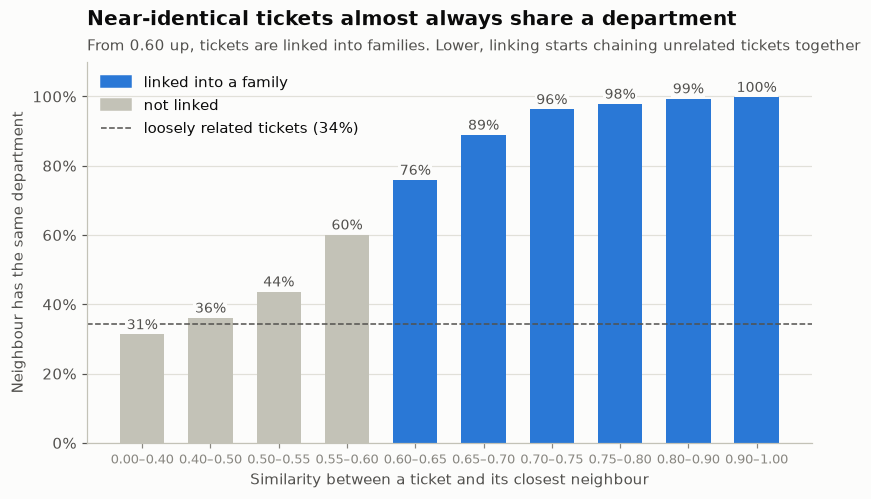

,tickets,same department
"[0.0, 0.4)",929,0.313
"[0.4, 0.5)",1507,0.361
"[0.5, 0.55)",655,0.437
"[0.55, 0.6)",629,0.601
"[0.6, 0.65)",705,0.759
"[0.65, 0.7)",1036,0.889
"[0.7, 0.75)",1424,0.963
"[0.75, 0.8)",1849,0.978
"[0.8, 0.9)",4900,0.994
"[0.9, 1.0)",2704,0.998


In [16]:
# Step 10 (chart) — the evidence for the threshold: how often a ticket's closest neighbour shares its department
from matplotlib.lines import Line2D

labels = df[LABEL].to_numpy()
same_dept = labels == labels[nearest_idx]
band_edges = [0, 0.4, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.9, 1.0001]
bands = pd.cut(nearest_sim, band_edges, right=False)
agreement = pd.DataFrame({
    "tickets": pd.Series(bands).value_counts(sort=False),
    "same department": pd.Series(same_dept).groupby(bands, observed=False).mean(),
})
loose_rate = same_dept[nearest_sim < 0.5].mean()
in_family = [iv.left >= FAMILY_THRESHOLD for iv in agreement.index]
band_names = [f"{iv.left:.2f}–{min(iv.right, 1):.2f}" for iv in agreement.index]
label_box = dict(facecolor=SURFACE, edgecolor="none", pad=1)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
x = np.arange(len(agreement))
ax.bar(x, agreement["same department"] * 100, width=0.65, color=[CAT[0] if f else AXIS for f in in_family])
ax.axhline(loose_rate * 100, color=INK_2, linestyle="--", linewidth=1, zorder=1)
for xi, v in zip(x, agreement["same department"] * 100):
    ax.text(xi, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9, color=INK_2, bbox=label_box, zorder=3)

ax.set_xticks(x, band_names, fontsize=8.5)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter())
ax.grid(axis="x", visible=False)
ax.set_xlabel("Similarity between a ticket and its closest neighbour")
ax.set_ylabel("Neighbour has the same department")
headline(ax, "Near-identical tickets almost always share a department",
         f"From {FAMILY_THRESHOLD:.2f} up, tickets are linked into families. Lower, linking starts chaining unrelated tickets together")
ax.legend(handles=[Patch(color=CAT[0], label="linked into a family"), Patch(color=AXIS, label="not linked"),
                   Line2D([0], [0], color=INK_2, linestyle="--", linewidth=1, label=f"loosely related tickets ({loose_rate:.0%})")],
          loc="upper left")
plt.show()

agreement.assign(**{"same department": agreement["same department"].round(3)})

In [17]:
# Step 10 (read) — what a pair right at the threshold looks like: are these really the same ticket reworded?
at_threshold = np.where((nearest_sim >= FAMILY_THRESHOLD) & (nearest_sim < FAMILY_THRESHOLD + 0.05))[0]
for i in np.random.default_rng(SEED).choice(at_threshold, size=3, replace=False):
    j = nearest_idx[i]
    print(f"similarity {nearest_sim[i]:.2f}")
    print(f"  ▸ [{labels[i]}] {df.at[i, 'text'][:150]}…")
    print(f"  ▸ [{labels[j]}] {df.at[j, 'text'][:150]}…\n")

similarity 0.65
  ▸ [IT Support] Concerns with Investment Analytics Dashboard Hello Customer Support, I am encountering difficulties with the investment analytics dashboard while prep…
  ▸ [Technical Support] Hello customer support, I am encountering an issue with the analytics dashboard report for investment performance metrics. The displayed data seems to…

similarity 0.64
  ▸ [Customer Service] Could you provide details on how digital strategies can effectively promote brand growth in companies? I am eager to understand the approach and the r…
  ▸ [Customer Service] Could you share information on how digital strategies can effectively promote brand development within organizations? I am eager to understand the met…

similarity 0.65
  ▸ [Returns and Exchanges] Problem with Project Management Tool Access We are encountering sporadic issues with the project management tool that are affecting user access. Recen…
  ▸ [Returns and Exchanges] Problem with Project Management Tool Login We a

*16,338 English tickets in 7,985 families; 77% have a reworded sibling — and some identical-meaning pairs carry different labels.*

---
# Phase 3 — Prepare for modelling
**How models are judged (fixed before training):** accuracy picks the winner · every class must have recall > 0 · models within 1 point are tied → higher macro F1 → gives probabilities.

## Steps 11–12 — Split 71 / 14 / 14 with families kept whole (asserted); no class is too rare to keep

In [18]:
# Steps 11–12 — rare-class check, then family-grouped stratified train / validation / test split; verify
from sklearn.model_selection import StratifiedGroupKFold

MIN_CLASS_SIZE = 30
dept_counts = df[LABEL].value_counts()
print(f"Classes below {MIN_CLASS_SIZE} tickets: {list(dept_counts[dept_counts < MIN_CLASS_SIZE].index) or 'none'}")

y_all, groups = df[LABEL].to_numpy(), df["family_id"].to_numpy()
all_idx = np.arange(len(df))

# 1 fold of 7 (~14.3%) → test; then 1 fold of 6 of the remainder (~14.3% of all) → validation
rest_idx, test_idx = next(StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED).split(all_idx, y_all, groups))
tr, va = next(StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED).split(rest_idx, y_all[rest_idx], groups[rest_idx]))
train_df, val_df, test_df = df.iloc[rest_idx[tr]], df.iloc[rest_idx[va]], df.iloc[test_idx]

splits = {"train": train_df, "validation": val_df, "test": test_df}
for (a, da), (b, db) in [(("train", train_df), ("validation", val_df)), (("train", train_df), ("test", test_df)),
                         (("validation", val_df), ("test", test_df))]:
    assert not set(da["family_id"]) & set(db["family_id"]), f"a family appears in both {a} and {b}"
print("No family crosses splits ✓")

mixed_families = df.groupby("family_id")[LABEL].nunique().gt(1)
print(f"Families holding more than one department: {mixed_families.sum():,} "
      f"({df['family_id'].map(mixed_families).sum():,} tickets) — kept as labelled\n")

split_summary = pd.DataFrame({name: s[LABEL].value_counts(normalize=True).mul(100) for name, s in splits.items()})
split_summary.loc["— tickets —"] = [len(s) for s in splits.values()]
split_summary.loc["— share of all —"] = [len(s) / len(df) * 100 for s in splits.values()]
gap = (split_summary.iloc[:-2].max(axis=1) - split_summary.iloc[:-2].min(axis=1)).max()
print(f"Largest difference in any department's share across splits: {gap:.2f} points")
split_summary.round(1)

Classes below 30 tickets: none


No family crosses splits ✓
Families holding more than one department: 177 (1,788 tickets) — kept as labelled

Largest difference in any department's share across splits: 0.04 points


,train,validation,test
queue,,,
Technical Support,29.0,29.0,29.0
Product Support,18.8,18.8,18.8
Customer Service,14.7,14.7,14.8
IT Support,11.9,11.9,11.9
Billing and Payments,9.8,9.8,9.8
Returns and Exchanges,5.0,5.0,5.0
Service Outages and Maintenance,4.1,4.1,4.1
Sales and Pre-Sales,3.1,3.2,3.1
Human Resources,2.1,2.1,2.1


## Steps 13–14 — TF-IDF features from train only; class weights tried both ways, not assumed

In [19]:
# Step 13 — fit TfidfVectorizer on train, transform val and test
TFIDF_PARAMS = dict(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)

vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])
y_train, y_val, y_test = train_df[LABEL], val_df[LABEL], test_df[LABEL]

print(f"Vocabulary learned from train: {len(vectorizer.vocabulary_):,} words and word pairs")
for name, X in [("train", X_train), ("validation", X_val), ("test", X_test)]:
    print(f"  {name:10s} {X.shape[0]:>6,} tickets × {X.shape[1]:,} features")

Vocabulary learned from train: 43,220 words and word pairs
  train      11,670 tickets × 43,220 features
  validation  2,334 tickets × 43,220 features
  test        2,334 tickets × 43,220 features


In [20]:
# Step 13 (read) — the words that most set each department apart, learned from train only
terms = vectorizer.get_feature_names_out()
distinctive = {}
for dept in y_train.value_counts().index:
    in_dept = (y_train == dept).to_numpy()
    lift = np.asarray(X_train[in_dept].mean(axis=0)).ravel() - np.asarray(X_train[~in_dept].mean(axis=0)).ravel()
    distinctive[dept] = ", ".join(terms[np.argsort(lift)[::-1][:8]])
pd.Series(distinctive, name="most distinctive words and word pairs").to_frame()

,most distinctive words and word pairs
Technical Support,"issue, software, the issue, problem, restarting, issues, breach, the problem"
Product Support,"engagement, targeting, not, brand, campaign, campaigns, results, efforts to"
Customer Service,"on, integrating, details, you, strategies, details on, could you, management"
IT Support,"server, network, tools, devices, system, digital tools, connectivity, restarting"
Billing and Payments,"billing, payment, the billing, subscription, you, options, services, details"
Returns and Exchanges,"returns, investment returns, investment, return, engagement, product, in investment, brand engagement"
Service Outages and Maintenance,"service, outage, outages, disruption, service outage, impacting, disruptions, network"
Sales and Pre-Sales,"solutions, information on, sales, saas, about, features, integration, details"
Human Resources,"employee, investment optimization, access, hospital systems, hr, employees, optimization, provide details"
General Inquiry,"engagement, improve, audience, our, enhance, smart home, results, home"


*Some departments look keyword-assigned: Returns and Exchanges is defined by "investment returns".*

---
# Phase 4 — Baseline models

## Step 15 — Score 7 models + 2 dummies (Logistic Regression, Linear SVM, Naive Bayes, Random Forest; plain and balanced) with family-grouped cross-validation on train

In [21]:
# Step 15 — score every model with 5-fold cross-validation on the training set, folds grouped by family
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_predict
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

candidates = {
    "Dummy — always biggest": DummyClassifier(strategy="most_frequent"),
    "Dummy — random by size": DummyClassifier(strategy="stratified", random_state=SEED),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Logistic Regression (balanced)": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Linear SVM": LinearSVC(),
    "Linear SVM (balanced)": LinearSVC(class_weight="balanced"),
    "Complement Naive Bayes": ComplementNB(),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED),
    "Random Forest (balanced)": RandomForestClassifier(n_estimators=300, random_state=SEED, class_weight="balanced"),
}
GROUPED_CV = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluate(y_true, y_pred, labels):
    recalls = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred),
            "macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "lowest class recall": recalls.min(),
            "weakest class": labels[recalls.argmin()]}, recalls

def score_models(data, target, labels):
    # every candidate, grouped cross-validation; vocabulary refit inside each fold
    rows, recalls, preds = {}, {}, {}
    for name, model in candidates.items():
        pipeline = make_pipeline(TfidfVectorizer(**TFIDF_PARAMS), clone(model))
        preds[name] = cross_val_predict(pipeline, data["text"], data[target], groups=data["family_id"], cv=GROUPED_CV, n_jobs=-1)
        rows[name], recalls[name] = evaluate(data[target], preds[name], labels)
    results = pd.DataFrame(rows).T.astype({m: float for m in ["accuracy", "macro F1", "weighted F1", "lowest class recall"]})
    results["passes guardrail"] = results["lowest class recall"] > 0
    return results, pd.DataFrame(recalls, index=labels).T, preds

departments = np.sort(y_train.unique())
cv_results, recall_table, cv_preds = score_models(train_df, LABEL, departments)
cv_results.sort_values("accuracy", ascending=False).round(3)

,accuracy,macro F1,weighted F1,lowest class recall,weakest class,passes guardrail
Random Forest,0.388,0.222,0.323,0.000,General Inquiry,False
Random Forest (balanced),0.384,0.287,0.359,0.006,General Inquiry,True
Complement Naive Bayes,0.384,0.247,0.342,0.006,General Inquiry,True
Logistic Regression,0.383,0.242,0.341,0.000,General Inquiry,False
Linear SVM,0.363,0.284,0.348,0.012,General Inquiry,True
Linear SVM (balanced),0.347,0.294,0.343,0.071,General Inquiry,True
Logistic Regression (balanced),0.345,0.297,0.345,0.071,General Inquiry,True
Dummy — always biggest,0.290,0.045,0.130,0.000,Billing and Payments,False
Dummy — random by size,0.167,0.101,0.166,0.018,General Inquiry,True


## Step 16 — Pick a model, check the pick on validation, and measure what a random split would have claimed

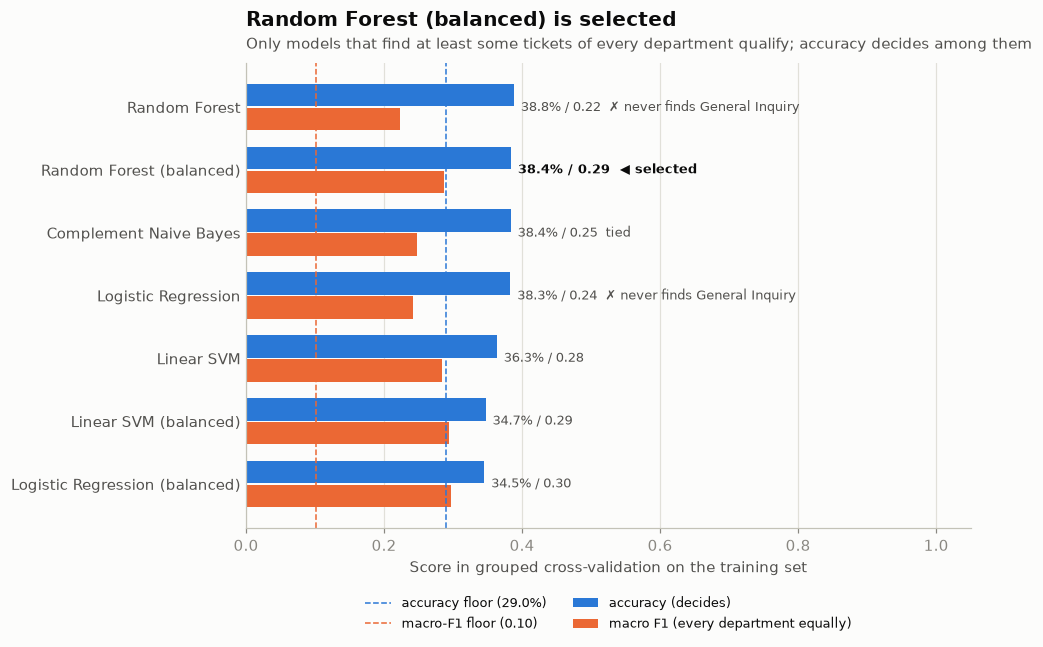

Selected: Random Forest (balanced)


,accuracy,macro F1,weighted F1,lowest class recall,weakest class,passes guardrail,gives probabilities
Complement Naive Bayes,0.384,0.247,0.342,0.006,General Inquiry,True,True
Random Forest (balanced),0.384,0.287,0.359,0.006,General Inquiry,True,True


In [22]:
# Step 16 — apply the selection rule and chart accuracy vs macro F1 per model (helpers reused in Phase 4B)
from sklearn.model_selection import KFold, cross_validate
TIE_TOLERANCE = 0.01

def select_model(results):
    models = results[~results.index.str.startswith("Dummy")]
    qualifying = models[models["passes guardrail"]]
    if qualifying.empty:
        return None, models, qualifying
    tied = qualifying[qualifying["accuracy"] >= qualifying["accuracy"].max() - TIE_TOLERANCE].copy()
    tied["gives probabilities"] = [hasattr(candidates[n], "predict_proba") for n in tied.index]
    return tied.sort_values(["macro F1", "gives probabilities"], ascending=False).index[0], models, tied

def plot_comparison(results, selected, models, tied, title, subtitle, class_word):
    floor_acc = results.loc["Dummy — always biggest", "accuracy"]
    floor_f1 = results.loc["Dummy — random by size", "macro F1"]
    plot_df = models.sort_values("accuracy")
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    y = np.arange(len(plot_df))
    ax.barh(y + 0.19, plot_df["accuracy"], height=0.36, color=CAT[0], label="accuracy (decides)")
    ax.barh(y - 0.19, plot_df["macro F1"], height=0.36, color=CAT[1], label=f"macro F1 (every {class_word} equally)")
    ax.axvline(floor_acc, color=CAT[0], linestyle="--", linewidth=1, label=f"accuracy floor ({floor_acc:.1%})")
    ax.axvline(floor_f1, color=CAT[1], linestyle="--", linewidth=1, label=f"macro-F1 floor ({floor_f1:.2f})")
    for yi, (name, r) in zip(y, plot_df.iterrows()):
        note = ("  ◀ selected" if name == selected else "  tied" if name in tied.index
                else "" if r["passes guardrail"] else f"  ✗ never finds {r['weakest class']}")
        ax.text(max(r["accuracy"], r["macro F1"]) + 0.01, yi, f"{r['accuracy']:.1%} / {r['macro F1']:.2f}{note}", va="center",
                fontsize=8.5, color=INK if name == selected else INK_2, fontweight="bold" if name == selected else "normal")
    ax.set_yticks(y, plot_df.index)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Score in grouped cross-validation on the training set")
    headline(ax, title, subtitle, hbar=True)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8.5)
    plt.show()

BEST_BASELINE, models_only, tied = select_model(cv_results)
plot_comparison(cv_results, BEST_BASELINE, models_only, tied,
                f"{BEST_BASELINE} is selected" if BEST_BASELINE else "No model passes the guardrail",
                "Only models that find at least some tickets of every department qualify; accuracy decides among them", "department")
print(f"Selected: {BEST_BASELINE}")
tied.round(3)

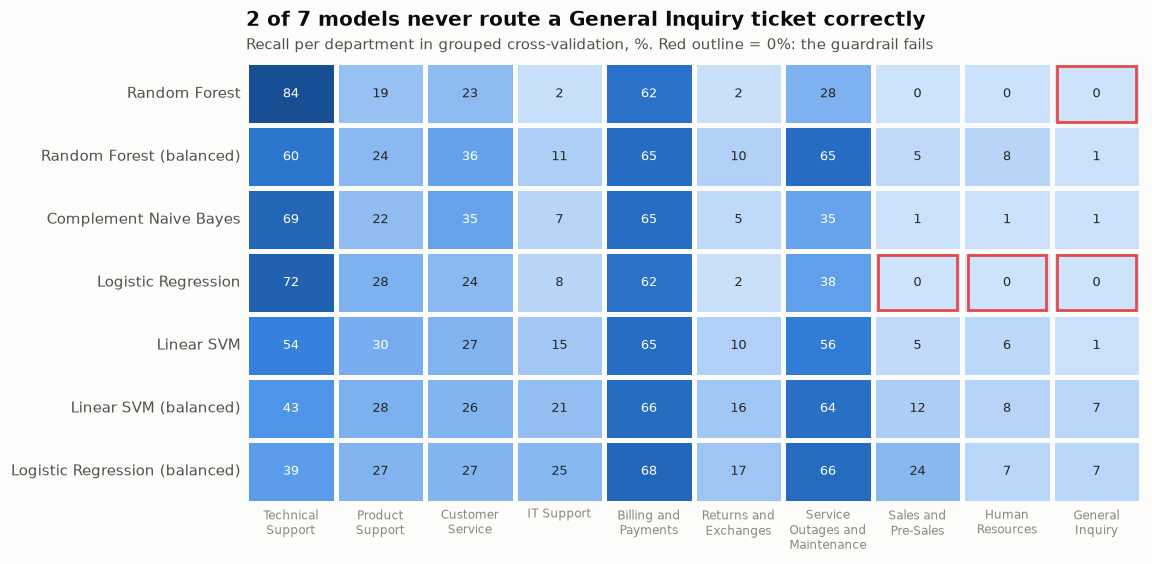

In [23]:
# Step 16 (guardrail, visible) — every model's recall per department in cross-validation
import textwrap

heat_df = recall_table.loc[models_only.sort_values("accuracy", ascending=False).index, list(dept_counts.index)] * 100
n_never = int((recall_table.loc[models_only.index, "General Inquiry"] == 0).sum())

fig, ax = plt.subplots(figsize=(10.5, 5.2))
sns.heatmap(heat_df, annot=True, fmt=".0f", cmap=BLUES, vmin=0, vmax=100, cbar=False, linewidths=2,
            linecolor=SURFACE, annot_kws={"fontsize": 8.5}, ax=ax)
for yi, name in enumerate(heat_df.index):
    for xi, v in enumerate(heat_df.loc[name]):
        if v == 0:
            ax.add_patch(plt.Rectangle((xi + 0.06, yi + 0.06), 0.88, 0.88, fill=False, edgecolor=CAT[7], linewidth=1.8))
ax.grid(False)
ax.tick_params(length=0)
ax.set_xticklabels([textwrap.fill(d, 12) for d in heat_df.columns], rotation=0, fontsize=8)
ax.set_xlabel("")
ax.set_ylabel("")
headline(ax, f"{n_never} of {len(heat_df)} models never route a General Inquiry ticket correctly",
         "Recall per department in grouped cross-validation, %. Red outline = 0%: the guardrail fails")
plt.show()

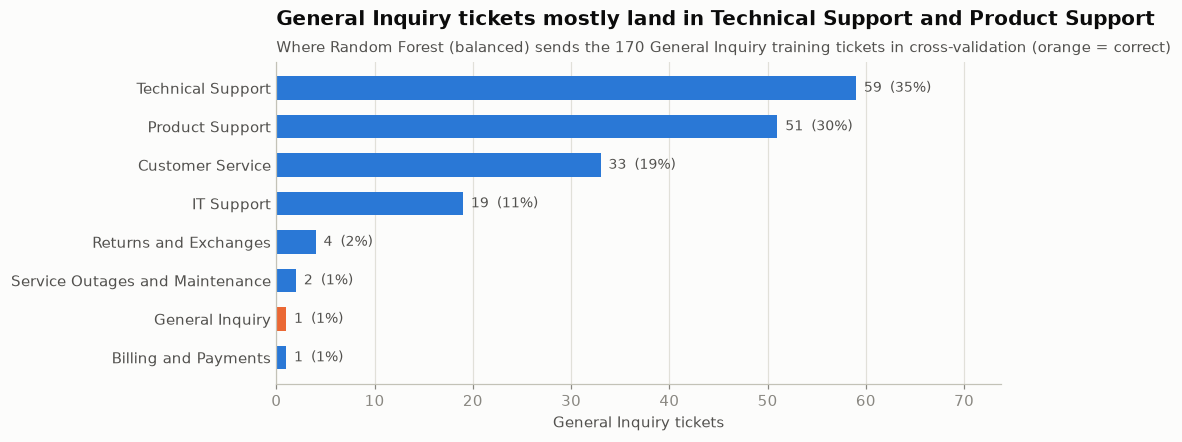

Most distinctive words (Step 13):
  General Inquiry      engagement, improve, audience, our, enhance, smart home, results, home
  Technical Support    issue, software, the issue, problem, restarting, issues, breach, the problem
  Product Support      engagement, targeting, not, brand, campaign, campaigns, results, efforts to


In [24]:
# Step 16 (diagnosis) — where do General Inquiry tickets actually go?
diagnosed = BEST_BASELINE or models_only["accuracy"].idxmax()
is_gi = (y_train == "General Inquiry").to_numpy()
routed = pd.Series(cv_preds[diagnosed][is_gi]).value_counts()

fig, ax = plt.subplots(figsize=(8.5, 3.8))
colors = [CAT[1] if d == "General Inquiry" else CAT[0] for d in routed.index[::-1]]
ax.barh(routed.index[::-1], routed.values[::-1], height=0.6, color=colors)
for yi, v in enumerate(routed.values[::-1]):
    ax.text(v + 0.8, yi, f"{v}  ({v / is_gi.sum():.0%})", va="center", fontsize=9, color=INK_2)
ax.set_xlim(0, routed.max() * 1.25)
ax.set_xlabel("General Inquiry tickets")
headline(ax, f"General Inquiry tickets mostly land in {routed.index[0]}" + (f" and {routed.index[1]}" if len(routed) > 1 else ""),
         f"Where {diagnosed} sends the {is_gi.sum()} General Inquiry training tickets in cross-validation (orange = correct)", hbar=True)
plt.show()

print("Most distinctive words (Step 13):")
for dept in ["General Inquiry", routed.index[0]] + ([routed.index[1]] if len(routed) > 1 else []):
    if dept in distinctive:
        print(f"  {dept:20s} {distinctive[dept]}")

Random Forest (balanced): cross-validation vs validation


,cross-validation (train),validation
accuracy,0.384,0.406
macro F1,0.287,0.302
weighted F1,0.359,0.379
lowest class recall,0.006,0.000


,accuracy,macro F1,weighted F1,lowest class recall,weakest class
Dummy — always biggest,0.29006,0.044968,0.130435,0.0,Billing and Payments
Dummy — random by size,0.180805,0.107684,0.180082,0.0,Human Resources
Random Forest (balanced),0.40617,0.302302,0.379315,0.0,General Inquiry


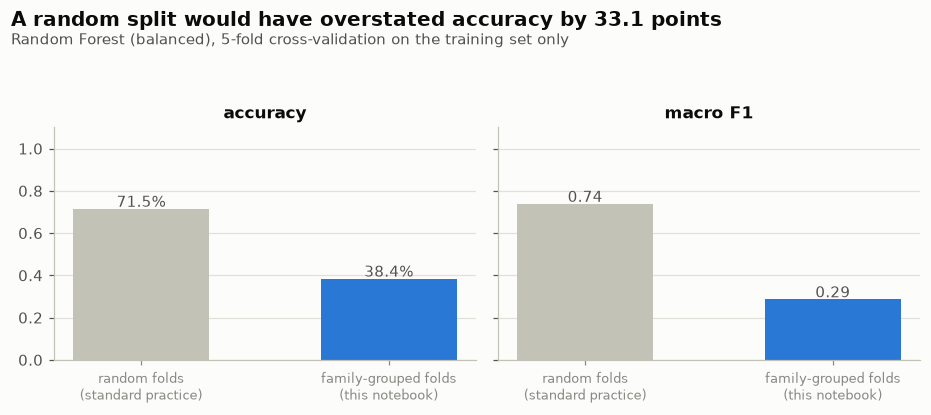

,accuracy,macro F1
random folds\n(standard practice),0.715,0.738
family-grouped folds\n(this notebook),0.384,0.286


In [25]:
# Step 16 (confirm + inflation) — validation check of the pick, then random vs family-grouped folds (helpers reused in 4B)
def confirm_on_validation(name, X_tr, y_tr, X_va, y_va, results, labels):
    val = {}
    for n in ["Dummy — always biggest", "Dummy — random by size", name]:
        val[n], _ = evaluate(y_va, clone(candidates[n]).fit(X_tr, y_tr).predict(X_va), labels)
    cols = ["accuracy", "macro F1", "weighted F1", "lowest class recall"]
    print(f"{name}: cross-validation vs validation")
    display(pd.DataFrame({"cross-validation (train)": results.loc[name, cols], "validation": pd.Series(val[name])[cols]}).astype(float).round(3))
    return pd.DataFrame(val).T.round(3)

def inflation_check(name, data, target):
    pipeline = make_pipeline(TfidfVectorizer(**TFIDF_PARAMS), clone(candidates[name]))
    schemes = {"random folds\n(standard practice)": KFold(n_splits=5, shuffle=True, random_state=SEED),
               "family-grouped folds\n(this notebook)": GROUPED_CV}
    scores = {}
    for label, cv in schemes.items():
        s = cross_validate(pipeline, data["text"], data[target], groups=data["family_id"] if cv is GROUPED_CV else None,
                           cv=cv, scoring={"accuracy": "accuracy", "macro F1": "f1_macro"}, n_jobs=-1)
        scores[label] = {"accuracy": s["test_accuracy"].mean(), "macro F1": s["test_macro F1"].mean()}
    scores = pd.DataFrame(scores).T
    gap = (scores.iloc[0] - scores.iloc[1])["accuracy"] * 100
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8), sharey=True)
    for ax, metric, fmt in zip(axes, ["accuracy", "macro F1"], ["{:.1%}", "{:.2f}"]):
        ax.bar(range(2), scores[metric], width=0.55, color=[AXIS, CAT[0]])
        for xi, v in enumerate(scores[metric]):
            ax.text(xi, v + 0.01, fmt.format(v), ha="center", fontsize=9.5, color=INK_2)
        ax.set_xticks(range(2), scores.index, fontsize=8.5)
        ax.set_title(metric, fontsize=11, loc="center")
        ax.grid(axis="x", visible=False)
    axes[0].set_ylim(0, 1.1)
    fig.suptitle(f"A random split would have overstated accuracy by {gap:.1f} points", x=0.01, ha="left", fontweight="bold", fontsize=13)
    fig.text(0.01, 0.9, f"{name}, 5-fold cross-validation on the training set only", fontsize=9.5, color=INK_2)
    fig.tight_layout(rect=(0, 0, 1, 0.88))
    plt.show()
    return scores.round(3)

confirmed = BEST_BASELINE or models_only["accuracy"].idxmax()
display(confirm_on_validation(confirmed, X_train, y_train, X_val, y_val, cv_results, departments))
inflation_check(confirmed, train_df, LABEL)

*Best department model: 38.4% (floor 29.0%); a random split would have claimed 71.5%. General Inquiry is essentially never found.*

---
# Checkpoint — Is the target column trustworthy?
**Test:** predict other columns from the *same* text, with the same honest split. If the text were the problem, nothing would work; if the label is, another label should.

In [26]:
# Checkpoint (test) — which column can actually be predicted from the ticket text? Training set only.
import warnings

coarse_department = {
    "Technical Support": "Tech / IT / Product", "IT Support": "Tech / IT / Product", "Product Support": "Tech / IT / Product",
    "Customer Service": "Customer / Sales / General", "Sales and Pre-Sales": "Customer / Sales / General",
    "General Inquiry": "Customer / Sales / General", "Billing and Payments": "Billing", "Returns and Exchanges": "Returns",
    "Service Outages and Maintenance": "Outages", "Human Resources": "HR",
}
target_candidates = {
    "queue — department, 10 (current)": train_df["queue"],
    "queue merged into 6 groups": train_df["queue"].map(coarse_department),
    "type — Incident / Request / Problem / Change": train_df["type"],
    "priority — low / medium / high": train_df["priority"],
    "tag_1 — first tag (many values)": train_df["tag_1"],
}
multi_member = train_df["family_id"].map(train_df["family_id"].value_counts()) > 1

target_rows = {}
for name, target in target_candidates.items():
    target = target.astype(str)
    with warnings.catch_warnings():  # rare tag values trigger "fewer members than folds" warnings; harmless here
        warnings.simplefilter("ignore")
        pred = cross_val_predict(make_pipeline(TfidfVectorizer(**TFIDF_PARAMS), LogisticRegression(max_iter=2000)),
                                 train_df["text"], target, groups=train_df["family_id"], cv=GROUPED_CV, n_jobs=-1)
    in_families = target[multi_member].groupby(train_df.loc[multi_member, "family_id"])
    target_rows[name] = {
        "classes": target.nunique(),
        "accuracy": accuracy_score(target, pred),
        "accuracy floor": target.value_counts(normalize=True).iloc[0],
        "macro F1": f1_score(target, pred, average="macro"),
        "macro-F1 floor": 1 / target.nunique(),
        "same label across rewordings": in_families.agg(lambda s: s.value_counts(normalize=True).iloc[0]).mean(),
    }
target_check = pd.DataFrame(target_rows).T.astype(float)
target_check["gain over floor (pts)"] = (target_check["accuracy"] - target_check["accuracy floor"]) * 100
target_check.round(3)

,classes,accuracy,accuracy floor,macro F1,macro-F1 floor,same label across rewordings,gain over floor (pts)
"queue — department, 10 (current)",10.0,0.383,0.290,0.242,0.100,0.981,9.306
queue merged into 6 groups,6.0,0.668,0.597,0.370,0.167,0.987,7.087
type — Incident / Request / Problem / Change,4.0,0.792,0.409,0.773,0.250,0.994,38.260
priority — low / medium / high,3.0,0.455,0.401,0.384,0.333,0.983,5.467
tag_1 — first tag (many values),69.0,0.762,0.200,0.120,0.014,0.902,56.178


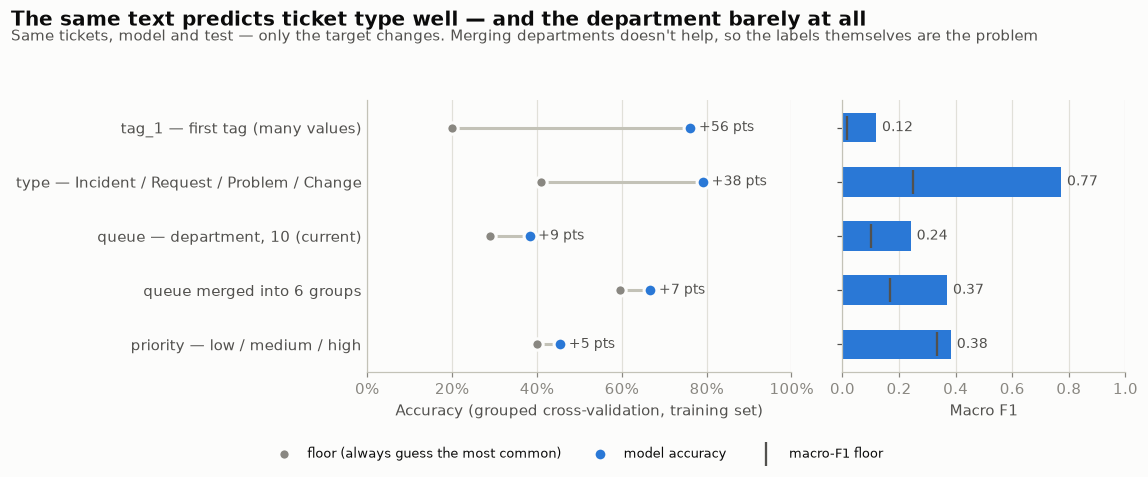

In [27]:
# Checkpoint (chart) — accuracy against each column's own floor, and macro F1
order = target_check.sort_values("gain over floor (pts)").index
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True, gridspec_kw={"width_ratios": [1.5, 1]})
y = np.arange(len(order))

ax1.hlines(y, target_check.loc[order, "accuracy floor"], target_check.loc[order, "accuracy"], color=AXIS, linewidth=2)
ax1.scatter(target_check.loc[order, "accuracy floor"], y, s=55, color=MUTED, edgecolor=SURFACE, linewidth=2, zorder=3, label="floor (always guess the most common)")
ax1.scatter(target_check.loc[order, "accuracy"], y, s=70, color=CAT[0], edgecolor=SURFACE, linewidth=2, zorder=3, label="model accuracy")
for yi, name in zip(y, order):
    ax1.text(target_check.loc[name, "accuracy"] + 0.02, yi, f"+{target_check.loc[name, 'gain over floor (pts)']:.0f} pts",
             va="center", fontsize=9, color=INK_2)
ax1.set_xlim(0, 1)
ax1.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax1.set_yticks(y, order)
ax1.tick_params(axis="y", length=0)
ax1.grid(axis="y", visible=False)
ax1.set_xlabel("Accuracy (grouped cross-validation, training set)")

ax2.barh(y, target_check.loc[order, "macro F1"], height=0.55, color=CAT[0])
ax2.scatter(target_check.loc[order, "macro-F1 floor"], y, marker="|", s=250, color=INK_2, zorder=3, label="macro-F1 floor")
for yi, name in zip(y, order):
    ax2.text(target_check.loc[name, "macro F1"] + 0.02, yi, f"{target_check.loc[name, 'macro F1']:.2f}", va="center", fontsize=9, color=INK_2)
ax2.set_xlim(0, 1)
ax2.grid(axis="y", visible=False)
ax2.set_xlabel("Macro F1")

fig.suptitle("The same text predicts ticket type well — and the department barely at all", x=0.01, ha="left",
             fontweight="bold", fontsize=13)
fig.text(0.01, 0.915, "Same tickets, model and test — only the target changes. Merging departments doesn't help, so the labels themselves are the problem",
         fontsize=9.5, color=INK_2)
handles = [h for a in (ax1, ax2) for h in a.get_legend_handles_labels()[0]]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=8.5, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=(0, 0.06, 1, 0.9))
plt.show()

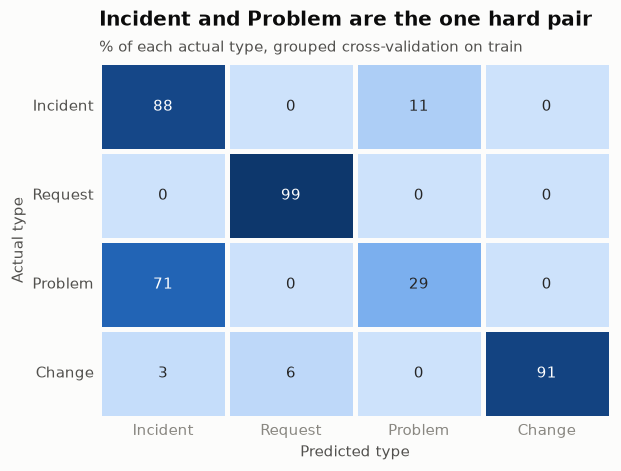

              precision    recall  f1-score   support

    Incident      0.705     0.884     0.784      4775
     Request      0.972     0.993     0.982      3203
     Problem      0.561     0.288     0.381      2446
      Change      0.984     0.912     0.946      1246

    accuracy                          0.792     11670
   macro avg      0.805     0.769     0.773     11670
weighted avg      0.778     0.792     0.771     11670



In [28]:
# Checkpoint (type up close) — per-class scores for the proposed target, and which types get confused
from sklearn.metrics import classification_report, confusion_matrix

type_pred = cross_val_predict(make_pipeline(TfidfVectorizer(**TFIDF_PARAMS), LogisticRegression(max_iter=2000)),
                              train_df["text"], train_df["type"], groups=train_df["family_id"], cv=GROUPED_CV, n_jobs=-1)
type_order = ["Incident", "Request", "Problem", "Change"]
type_cm = pd.DataFrame(confusion_matrix(train_df["type"], type_pred, labels=type_order, normalize="true") * 100,
                       index=type_order, columns=type_order)

fig, ax = plt.subplots(figsize=(6, 4.2))
sns.heatmap(type_cm, annot=True, fmt=".0f", cmap=BLUES, vmin=0, vmax=100, cbar=False, linewidths=2,
            linecolor=SURFACE, annot_kws={"fontsize": 10}, ax=ax)
ax.grid(False)
ax.tick_params(length=0)
ax.set_yticklabels(type_order, rotation=0)
ax.set_xlabel("Predicted type")
ax.set_ylabel("Actual type")
headline(ax, "Incident and Problem are the one hard pair", "% of each actual type, grouped cross-validation on train")
plt.show()

print(classification_report(train_df["type"], type_pred, labels=type_order, digits=3))

### Decision: predict ticket `type` from here on
Type is learnable (~79% vs 41% floor), consistent across rewordings (99%), and a real routing decision (on-call, service desk, change, root cause). Department is not. `type` stays banned as an *input*; all other rules carry over.

---
# Phase 4B — Rebuild on ticket `type`
*Split re-drawn stratified by type — legitimate, because the test set has never been opened.*

In [29]:
# Phase 4B (split) — re-draw train / validation / test, stratified by type, grouped by family; verify
LABEL = "type"  # the target from here on
TYPES = np.array(["Incident", "Request", "Problem", "Change"])

y_all, groups = df[LABEL].to_numpy(), df["family_id"].to_numpy()
rest_idx, test_idx = next(StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED).split(np.arange(len(df)), y_all, groups))
tr, va = next(StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED).split(rest_idx, y_all[rest_idx], groups[rest_idx]))
train_df, val_df, test_df = df.iloc[rest_idx[tr]], df.iloc[rest_idx[va]], df.iloc[test_idx]
y_train, y_val, y_test = train_df[LABEL], val_df[LABEL], test_df[LABEL]

splits = {"train": train_df, "validation": val_df, "test": test_df}
for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    assert not set(splits[a]["family_id"]) & set(splits[b]["family_id"]), f"a family appears in both {a} and {b}"
print("No family crosses splits ✓")

mixed = df.groupby("family_id")[LABEL].nunique().gt(1)
print(f"Families holding more than one type: {mixed.sum():,} ({df['family_id'].map(mixed).sum():,} tickets) — kept as labelled\n")

type_split = pd.DataFrame({n: s[LABEL].value_counts(normalize=True).mul(100) for n, s in splits.items()}).loc[TYPES]
print(f"Largest difference in any type's share across splits: {(type_split.max(axis=1) - type_split.min(axis=1)).max():.2f} points")
type_split.loc["— tickets —"] = [len(s) for s in splits.values()]
type_split.round(1)

No family crosses splits ✓
Families holding more than one type: 70 (1,105 tickets) — kept as labelled

Largest difference in any type's share across splits: 0.04 points


,train,validation,test
type,,,
Incident,40.2,40.2,40.2
Request,28.6,28.5,28.5
Problem,20.8,20.8,20.8
Change,10.4,10.5,10.5
— tickets —,11670.0,2334.0,2334.0


In [30]:
# Phase 4B (features) — refit TF-IDF on the new training set; the words that set each type apart
vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])
print(f"Vocabulary learned from train: {len(vectorizer.vocabulary_):,} words and word pairs\n")

terms = vectorizer.get_feature_names_out()
type_words = {}
for t in TYPES:
    in_type = (y_train == t).to_numpy()
    lift = np.asarray(X_train[in_type].mean(axis=0)).ravel() - np.asarray(X_train[~in_type].mean(axis=0)).ravel()
    type_words[t] = ", ".join(terms[np.argsort(lift)[::-1][:10]])
pd.Series(type_words, name="most distinctive words and word pairs").to_frame()

Vocabulary learned from train: 43,077 words and word pairs



,most distinctive words and word pairs
Incident,"issue, have, recent, the issue, problem, has, system, been, due to, due"
Request,"you, on, could you, for, you provide, about, information on, information, details, provide"
Problem,"due to, due, problem, issue, have, facing, despite, issues, be due, might"
Change,"improve, request, enhance, current, update, for, our, an update, enhancements, to improve"


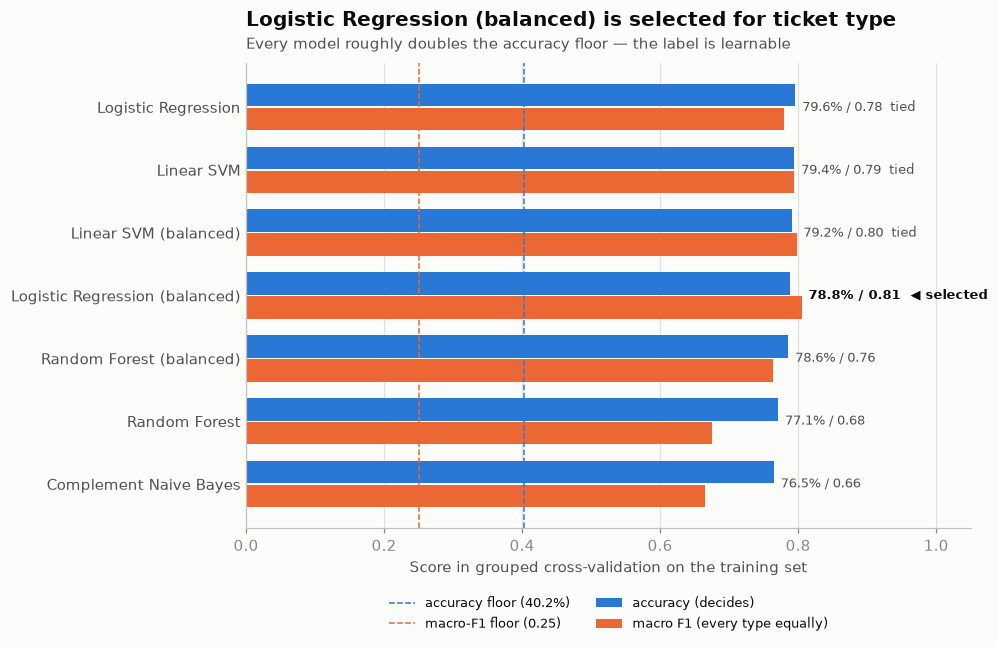

Selected: Logistic Regression (balanced)


,accuracy,macro F1,weighted F1,lowest class recall,weakest class,passes guardrail,gives probabilities
Logistic Regression,0.796,0.780,0.779,0.320,Problem,True,True
Logistic Regression (balanced),0.788,0.805,0.790,0.566,Problem,True,True
Linear SVM,0.794,0.793,0.786,0.396,Problem,True,False
Linear SVM (balanced),0.792,0.798,0.787,0.443,Problem,True,False


In [31]:
# Phase 4B (models) — every candidate scored with grouped cross-validation, then the Phase 3 rule picks one
type_results, _, type_preds = score_models(train_df, LABEL, TYPES)
BEST_TYPE_MODEL, type_models, type_tied = select_model(type_results)
plot_comparison(type_results, BEST_TYPE_MODEL, type_models, type_tied, f"{BEST_TYPE_MODEL} is selected for ticket type",
                "Every model roughly doubles the accuracy floor — the label is learnable", "type")
print(f"Selected: {BEST_TYPE_MODEL}")
type_tied.round(3)

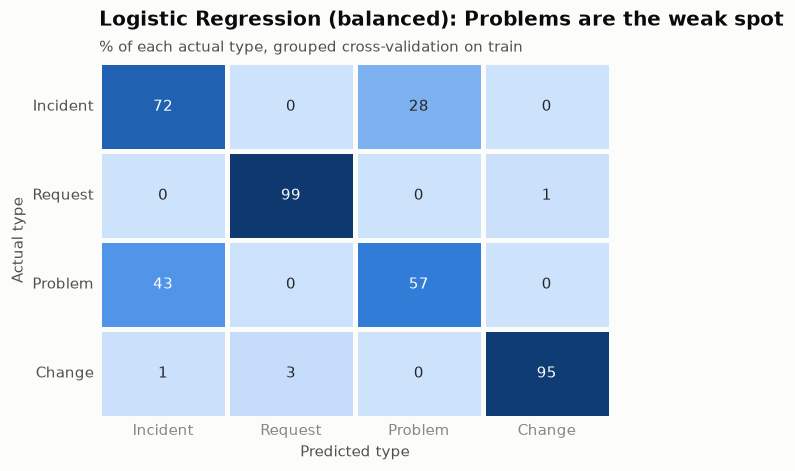

              precision    recall  f1-score   support

    Incident      0.761     0.719     0.739      4694
     Request      0.984     0.987     0.985      3333
     Problem      0.510     0.566     0.537      2426
      Change      0.963     0.954     0.959      1217

    accuracy                          0.788     11670
   macro avg      0.805     0.806     0.805     11670
weighted avg      0.794     0.788     0.790     11670



In [32]:
# Phase 4B (errors) — where the selected model goes wrong, by type (cross-validation on train)
sel_cm = pd.DataFrame(confusion_matrix(y_train, type_preds[BEST_TYPE_MODEL], labels=TYPES, normalize="true") * 100,
                      index=TYPES, columns=TYPES)
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.heatmap(sel_cm, annot=True, fmt=".0f", cmap=BLUES, vmin=0, vmax=100, cbar=False, linewidths=2,
            linecolor=SURFACE, annot_kws={"fontsize": 10}, ax=ax)
ax.grid(False)
ax.tick_params(length=0)
ax.set_yticklabels(TYPES, rotation=0)
ax.set_xlabel("Predicted type")
ax.set_ylabel("Actual type")
headline(ax, f"{BEST_TYPE_MODEL}: Problems are the weak spot", "% of each actual type, grouped cross-validation on train")
plt.show()
print(classification_report(y_train, type_preds[BEST_TYPE_MODEL], labels=TYPES, digits=3))

Logistic Regression (balanced): cross-validation vs validation


,cross-validation (train),validation
accuracy,0.788,0.790
macro F1,0.805,0.807
weighted F1,0.790,0.792
lowest class recall,0.566,0.577


,accuracy,macro F1,weighted F1,lowest class recall,weakest class
Dummy — always biggest,0.402314,0.143446,0.230842,0.0,Request
Dummy — random by size,0.303342,0.25464,0.302187,0.122951,Change
Logistic Regression (balanced),0.789632,0.807491,0.79232,0.57732,Problem


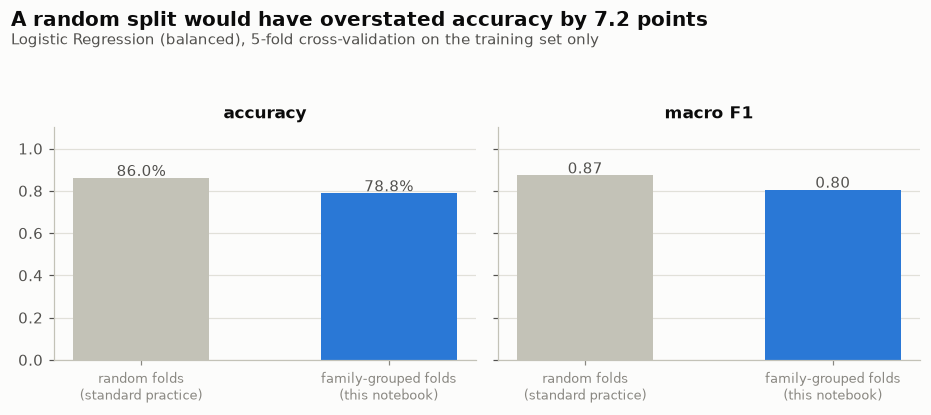

,accuracy,macro F1
random folds\n(standard practice),0.860,0.873
family-grouped folds\n(this notebook),0.788,0.805


In [33]:
# Phase 4B (confirm + inflation) — validation check of the pick, then random vs family-grouped folds
display(confirm_on_validation(BEST_TYPE_MODEL, X_train, y_train, X_val, y_val, type_results, TYPES))
inflation_check(BEST_TYPE_MODEL, train_df, LABEL)

*Selected: Logistic Regression (balanced) — 78.8% (floor 40.2%), validation 79.0%, random split would claim 86.0%. Weak spot: Incident vs Problem.*

---
# Phase 5 — Improve
## Step 17 — What the model reads, then tune it
**Decision rule for tuning:** the tuned version replaces the baseline only if it gains more than 1 point of accuracy (the noise band); otherwise the simpler baseline stays.

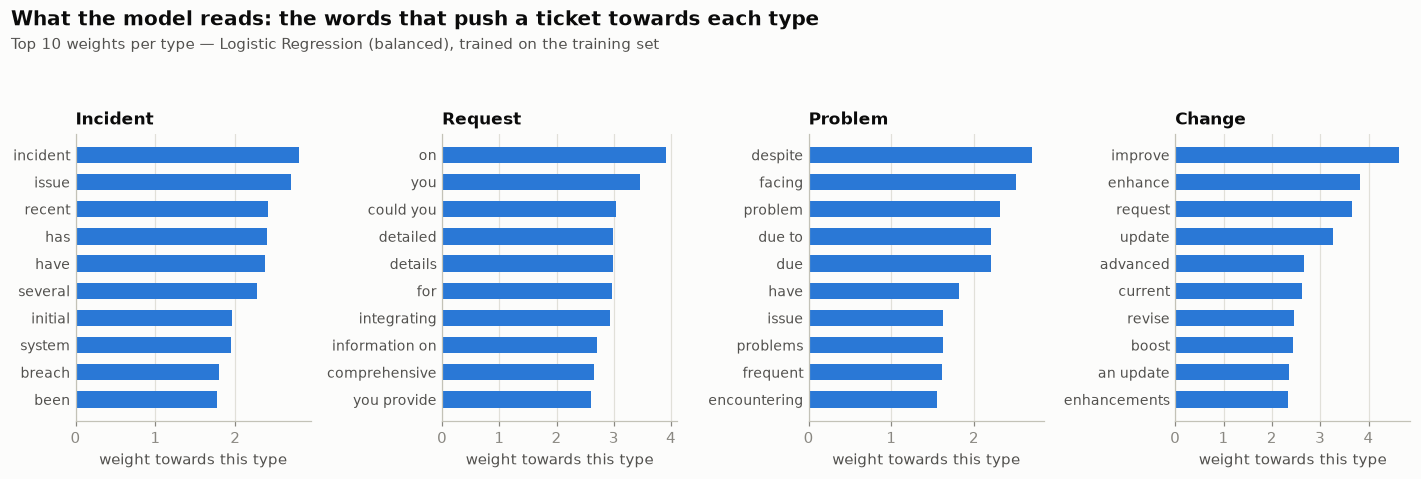

In [34]:
# Step 17 (read) — the words that push a ticket hardest towards each type (Logistic Regression weights)
reader = clone(candidates[BEST_TYPE_MODEL]).fit(X_train, y_train)
terms = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(1, 4, figsize=(13, 4.4))
for ax, t in zip(axes, TYPES):
    weights = reader.coef_[list(reader.classes_).index(t)]
    top = np.argsort(weights)[::-1][:10][::-1]
    ax.barh(terms[top], weights[top], height=0.6, color=CAT[0])
    ax.set_title(t, fontsize=11, loc="left")
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", length=0, labelsize=9)
    ax.set_xlabel("weight towards this type")
fig.suptitle("What the model reads: the words that push a ticket towards each type", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.text(0.01, 0.9, f"Top 10 weights per type — {BEST_TYPE_MODEL}, trained on the training set", fontsize=9.5, color=INK_2)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

In [35]:
# Step 17 (tune) — randomized search over features + model settings; family-grouped CV on train; Phase 3 rule picks
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV

def pick_by_rule(cv):
    # accuracy decides; configurations within 1 point of the best are tied → highest macro F1
    acc, f1 = np.asarray(cv["mean_test_accuracy"]), np.asarray(cv["mean_test_macro F1"])
    tied = np.where(acc >= acc.max() - TIE_TOLERANCE)[0]
    return int(tied[np.argmax(f1[tied])])

model_space = {"logisticregression__C": loguniform(0.1, 100), "logisticregression__class_weight": [None, "balanced"]}
search_space = [
    {"tfidfvectorizer__analyzer": ["word"], "tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)],
     "tfidfvectorizer__min_df": [1, 2, 3, 5], "tfidfvectorizer__max_df": [0.8, 0.9, 1.0],
     "tfidfvectorizer__sublinear_tf": [True, False], **model_space},
    {"tfidfvectorizer__analyzer": ["char_wb"], "tfidfvectorizer__ngram_range": [(3, 5)],
     "tfidfvectorizer__min_df": [2, 5], "tfidfvectorizer__sublinear_tf": [True], **model_space},
]
search = RandomizedSearchCV(make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=3000)), search_space, n_iter=30,
                            scoring={"accuracy": "accuracy", "macro F1": "f1_macro"}, refit=pick_by_rule,
                            cv=GROUPED_CV, random_state=SEED, n_jobs=-1)
search.fit(train_df["text"], y_train, groups=train_df["family_id"])

tuning = pd.DataFrame(search.cv_results_["params"]).rename(columns=lambda c: c.split("__")[1]).fillna({"class_weight": "none", "max_df": 1.0})
tuning["accuracy"] = search.cv_results_["mean_test_accuracy"]
tuning["macro F1"] = search.cv_results_["mean_test_macro F1"]
tuning["selected"] = tuning.index == search.best_index_
pd.concat([tuning.loc[[search.best_index_]], tuning.drop(search.best_index_).sort_values("accuracy", ascending=False).head(7)]).round(3)

,C,class_weight,analyzer,max_df,min_df,ngram_range,sublinear_tf,accuracy,macro F1,selected
25,0.857,balanced,word,0.8,3,"(1, 2)",True,0.786,0.804,True
8,89.062,none,word,1.0,1,"(1, 3)",True,0.796,0.791,False
27,4.829,none,word,0.9,3,"(1, 3)",True,0.796,0.789,False
19,0.652,none,word,0.9,1,"(1, 1)",True,0.796,0.784,False
29,2.668,none,word,0.9,1,"(1, 3)",True,0.795,0.779,False
26,2.610,none,word,1.0,2,"(1, 3)",True,0.794,0.782,False
4,0.351,none,char_wb,1.0,2,"(3, 5)",True,0.793,0.770,False
1,2.175,none,word,1.0,3,"(1, 1)",False,0.792,0.792,False


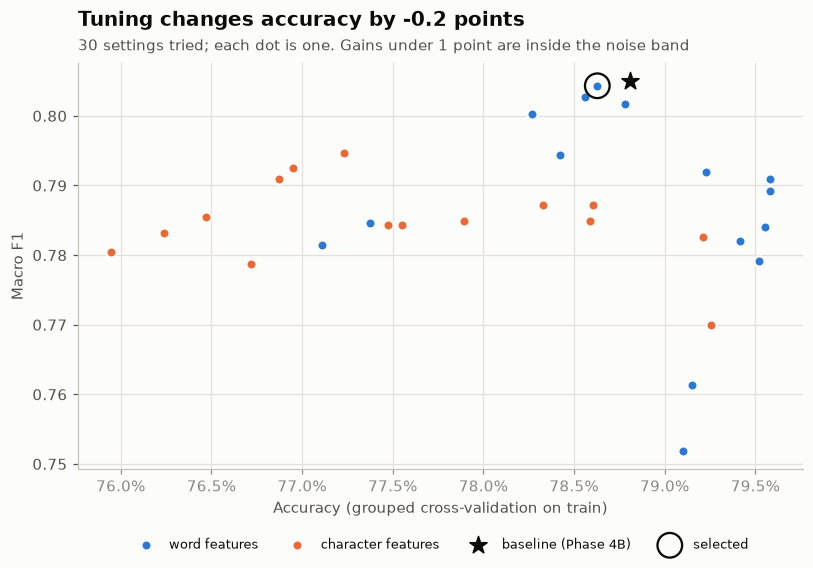

Per-type recall of the tuned settings: {'Incident': 0.709, 'Request': 0.988, 'Problem': 0.574, 'Change': 0.954}



Baseline 78.8% → tuned 78.6% (-0.2 pts). Inside the noise band — the simpler baseline stays.


In [36]:
# Step 17 (decide) — did tuning beat the baseline by more than the noise band? Guardrail re-checked on the pick
baseline_acc, baseline_f1 = type_results.loc[BEST_TYPE_MODEL, ["accuracy", "macro F1"]]
tuned = tuning.loc[search.best_index_]
gain = (tuned["accuracy"] - baseline_acc) * 100

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for analyzer, color, name in [("word", CAT[0], "word features"), ("char_wb", CAT[1], "character features")]:
    part = tuning[tuning["analyzer"] == analyzer]
    ax.scatter(part["accuracy"], part["macro F1"], s=45, color=color, edgecolor=SURFACE, linewidth=1.5, label=name, zorder=3)
ax.scatter(baseline_acc, baseline_f1, s=140, marker="*", color=INK, zorder=4, label="baseline (Phase 4B)")
ax.scatter(tuned["accuracy"], tuned["macro F1"], s=260, facecolor="none", edgecolor=INK, linewidth=1.5, zorder=4, label="selected")
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=1))
ax.set_xlabel("Accuracy (grouped cross-validation on train)")
ax.set_ylabel("Macro F1")
headline(ax, f"Tuning changes accuracy by {gain:+.1f} points",
         f"{len(tuning)} settings tried; each dot is one. Gains under {TIE_TOLERANCE * 100:.0f} point are inside the noise band")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=4, fontsize=8.5)
plt.show()

tuned_pred = cross_val_predict(clone(search.best_estimator_), train_df["text"], y_train, groups=train_df["family_id"], cv=GROUPED_CV, n_jobs=-1)
tuned_metrics, tuned_recalls = evaluate(y_train, tuned_pred, TYPES)
print("Per-type recall of the tuned settings:", {str(t): round(float(r), 3) for t, r in zip(TYPES, tuned_recalls)})

USE_TUNED = gain > TIE_TOLERANCE * 100 and tuned_recalls.min() > 0
FINAL_PIPELINE = search.best_estimator_ if USE_TUNED else make_pipeline(
    TfidfVectorizer(**TFIDF_PARAMS), clone(candidates[BEST_TYPE_MODEL])).fit(train_df["text"], y_train)
print(f"\nBaseline {baseline_acc:.1%} → tuned {tuned['accuracy']:.1%} ({gain:+.1f} pts). "
      + ("Tuned settings kept." if USE_TUNED else "Inside the noise band — the simpler baseline stays."))

*Tuning 30 settings — word vs character features, n-grams, regularisation, class weights — changes accuracy by −0.2 points: inside the noise. The bag-of-words model is at its ceiling on this data, so the simpler baseline stays. A bigger jump would need a different kind of model (e.g. sentence embeddings).*

---
## Next: error analysis → confidence calibration → one final test on the sealed test set